## Titanic Dataset

- The data has been split into two groups:

        1. training set (train.csv)
        2. test set (test.csv)

- The training set should be used to build your machine learning models. For the training set, we provide the outcome (also known as the “ground truth”) for each passenger. Your model will be based on “features” like passengers’ gender and class. use feature engineering for create new features if need.

- The test set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Features and Their Importance

- **PassengerId** – Unique passenger identifier; not useful for survival prediction.  
- **Survived** – Target variable (0 = died, 1 = survived); what we want to predict.  
- **Pclass** – Ticket class (1st/2nd/3rd) reflecting socio-economic status; strong survival predictor.  
- **Name** – Passenger name; can be engineered for titles (Mr., Mrs., etc.) to improve predictions.  
- **Sex** – Gender of passenger; one of the strongest survival indicators.  
- **Age** – Passenger age; important (children had higher survival).  
- **SibSp** – Number of siblings/spouses aboard; moderately important (family survival influence).  
- **Parch** – Number of parents/children aboard; moderately important (family ties).  
- **Ticket** – Ticket number; mostly useless
- **Fare** – Price of ticket; important (wealthier passengers had better survival odds).  
- **Cabin** – Cabin number; useful if cleaned, indicates location on ship but often missing.  
- **Embarked** – Port of embarkation (C/Q/S); mildly useful (slight survival differences).  


In [7]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [37]:
df.isnull().sum()

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age               177
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             687
Embarked            2
FamilySize          0
CabinAvailable      0
dtype: int64

1. **Survival Distribution**
   - Bar plot of `Survived` (0 vs 1) to see overall survival rate.

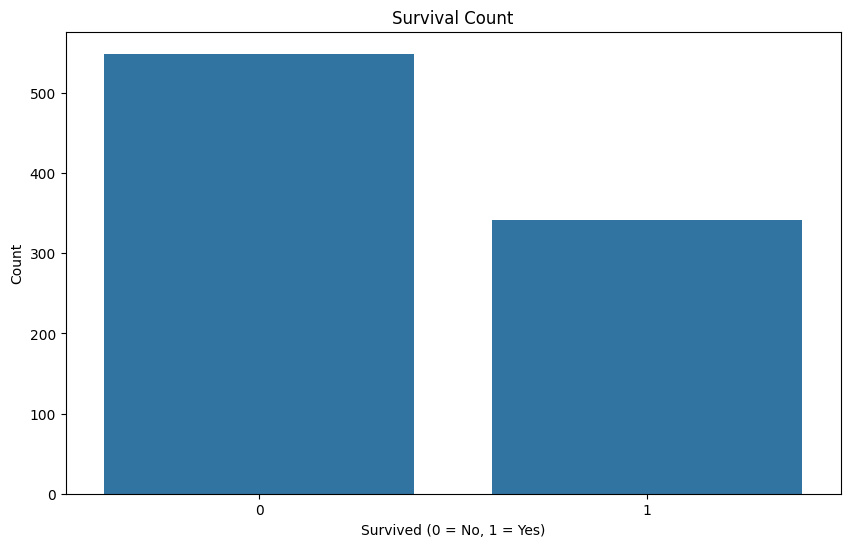

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

- The data is quite imbalance like 6:4

2. **Class vs Survival**
   - stacked bar chart of `Pclass` vs `Survived` to see if higher classes had better survival rates.

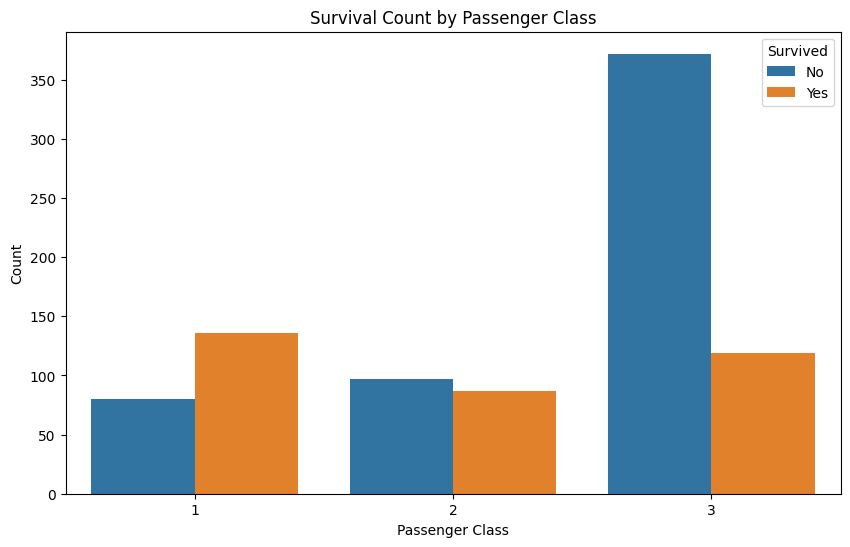

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

- The stacked bar chart shows that passengers in higher classes (Pclass 1) had a significantly higher survival rate compared to those in lower classes (Pclass 2 and 3). 
- Most survivors were from the first class, while the majority of deaths occurred in the third class. 
- This indicates that economic status, as represented by ticket class, played a crucial role in survival chances on the Titanic.

3. **Gender vs Survival**
   - Bar plot of `Sex` vs `Survived` to confirm survival differences between males and females.

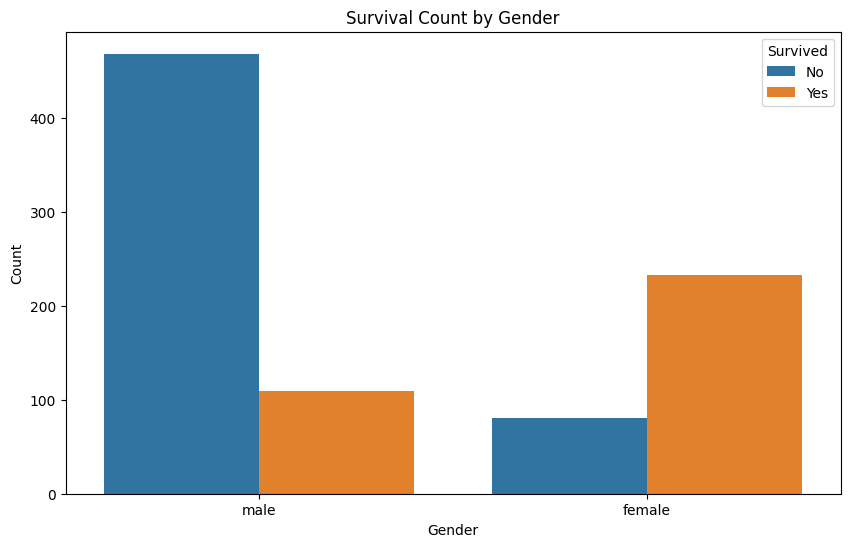

In [10]:
plt.figure(figsize=(10,6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

- Clearly seen that survival ratio of female is more

4. **Age Distribution**
   - Histogram & KDE plot of `Age` for survivors vs non-survivors to observe age-based patterns.
   - Boxplot of `Age` grouped by `Survived`.


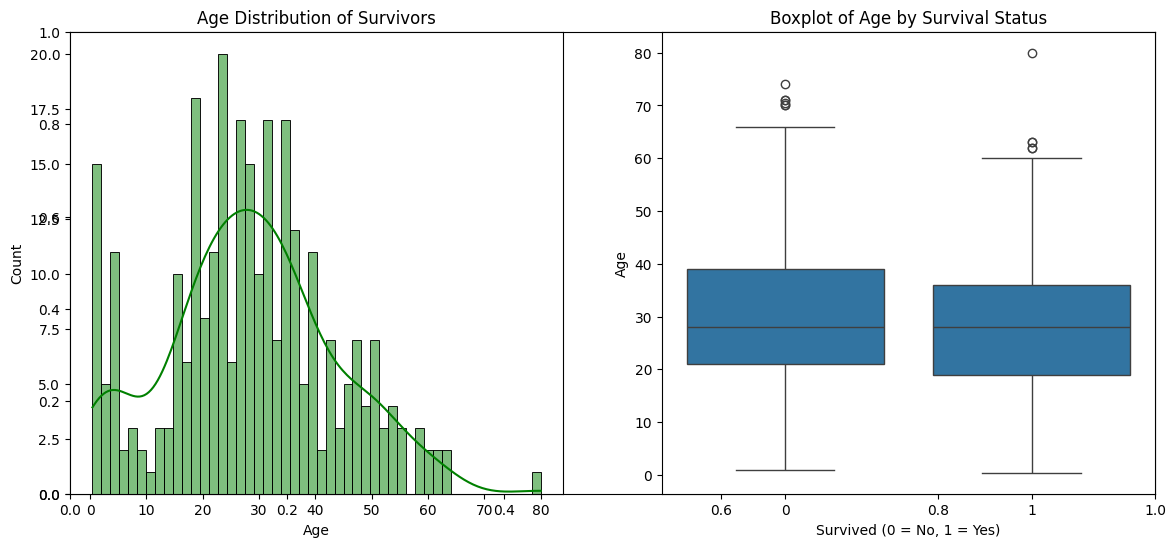

In [19]:
plt.subplots(figsize=(14,6))
plt.subplot(1, 2, 1)
sns.histplot(df[df['Survived'] == 1]['Age'].dropna(), kde=True, color='green', bins=50)
plt.title('Age Distribution of Survivors')
plt.xlabel('Age')
plt.ylabel('Count')


plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Boxplot of Age by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

- Younger passengers, especially children and young adults, had higher survival rates. 
- The median age of survivors and non-survivors is similar, but survival chances decrease with age.

5. **Fare vs Survival**
   - Histogram, boxplot of `Fare` for survivors vs non-survivors to see if higher fares improved survival chances.


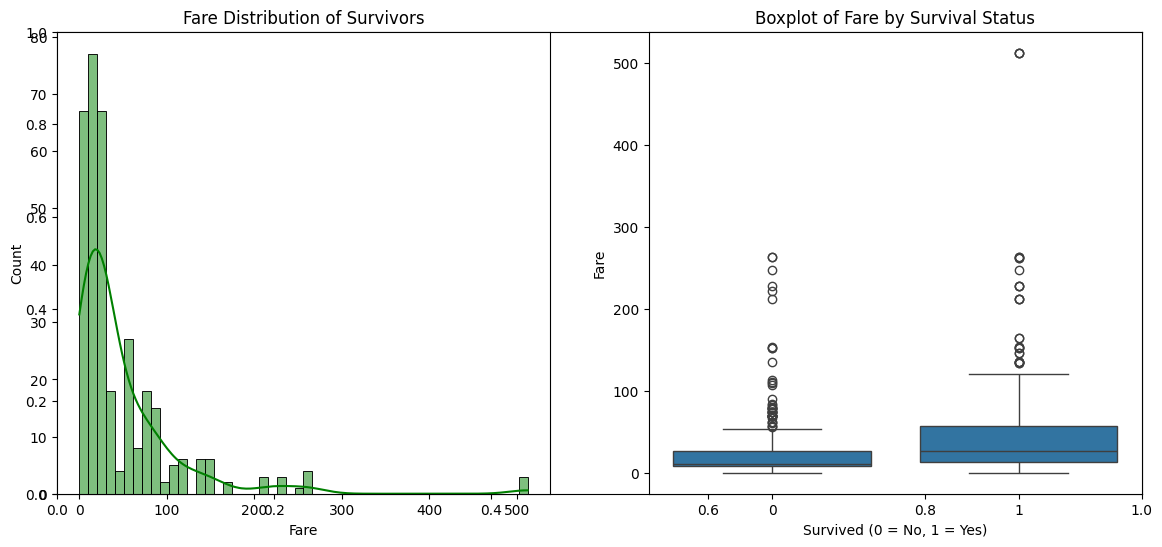

In [20]:
plt.subplots(figsize=(14,6))
plt.subplot(1, 2, 1)
sns.histplot(df[df['Survived'] == 1]['Fare'].dropna(), kde=True, color='green', bins=50)
plt.title('Fare Distribution of Survivors')
plt.xlabel('Fare')
plt.ylabel('Count')


plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Boxplot of Fare by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

6. **Family Size Effect**
   - Created a feature `FamilySize = SibSp + Parch + 1` and plot bar chart vs `Survived` to analyze survival of families vs solo travelers.



C:\Users\Dell\AppData\Local\Temp\ipykernel_22868\3897511562.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df, ci=None)


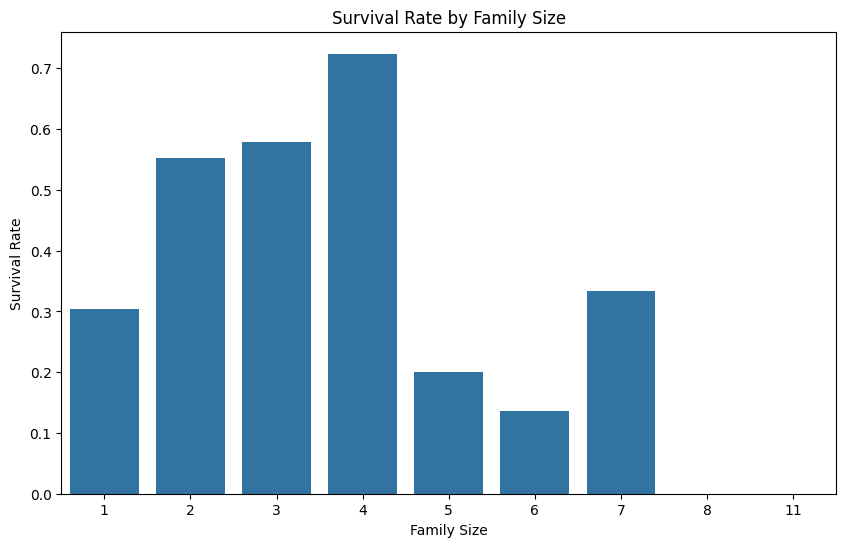

In [21]:
# Create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(10,6))
sns.barplot(x='FamilySize', y='Survived', data=df, ci=None)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

  - Passengers with small families (2–4 members) had the highest survival rates. 
  - Solo travelers and those with large families were less likely to survive.
  - Moderate family size seems to have provided the best chance of survival.

7. **Embarkation Port vs Survival**
   - Bar plot of `Embarked` vs `Survived` to check survival rates across boarding ports.


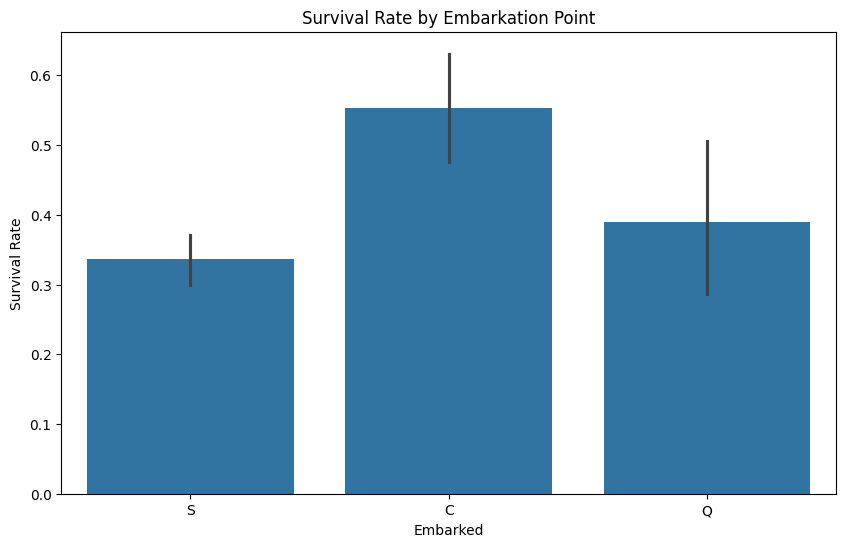

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Embarkation Point')
plt.xlabel('Embarked')
plt.ylabel('Survival Rate')
plt.show()

- Survival rates varied by embarkation port. 
- Passengers who boarded at Cherbourg (C) had the highest survival rate, while those from Southampton (S) had the lowest.

8. **Cabin Availability**
   - Bar plot comparing survival rate of passengers with a known `Cabin` vs missing `Cabin` values.


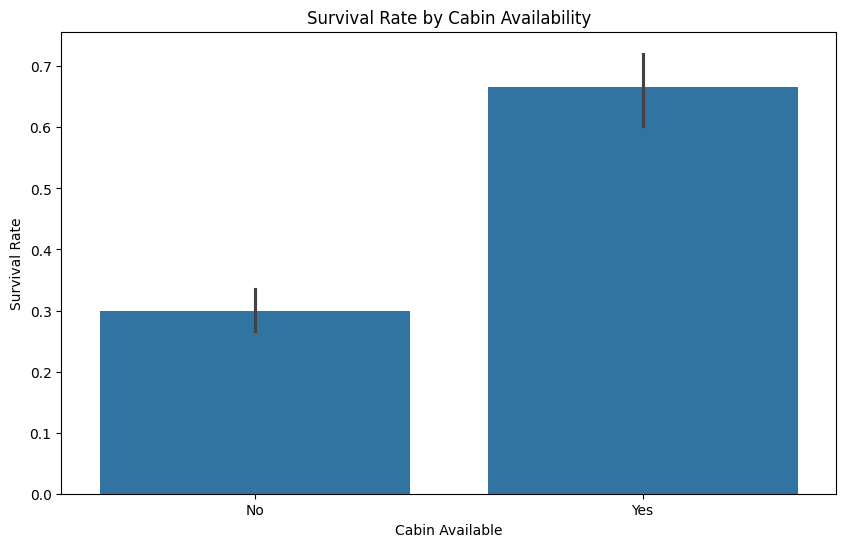

In [26]:
# Create a feature for Cabin availability
df['CabinAvailable'] = df['Cabin'].notnull()

plt.figure(figsize=(10,6))
sns.barplot(x='CabinAvailable', y='Survived', data=df)
plt.title('Survival Rate by Cabin Availability')
plt.xlabel('Cabin Available')
plt.ylabel('Survival Rate')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [35]:
df['Cabin'].isnull().sum()

np.int64(687)

In [36]:
df['Cabin'].nunique()

147

- more than 70% is null so we will drop it 

9. **Age vs Fare Scatterplot**
   - Scatterplot of `Age` vs `Fare` colored by `Survived` to visualize combined effects.

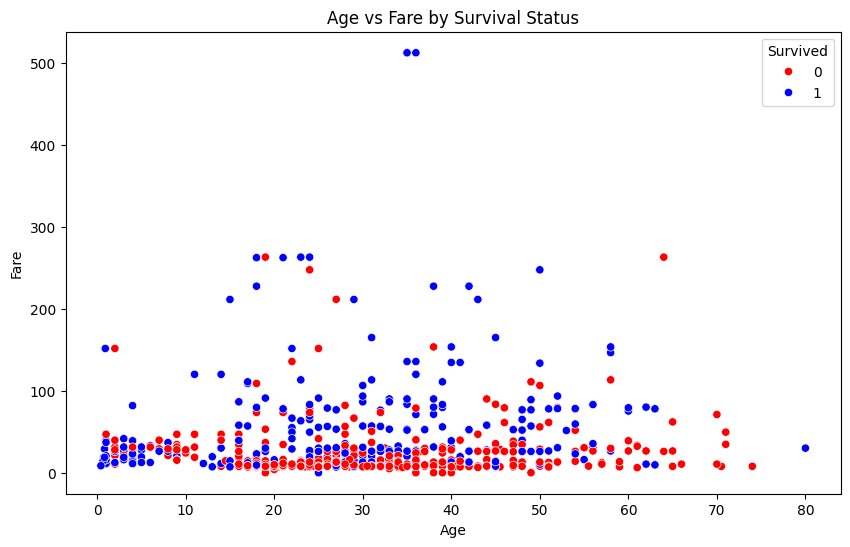

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, palette=['red', 'blue'])
plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived')
plt.show()

- The scatterplot shows that most survivors (blue) paid higher fares and were generally younger. 
- Non-survivors (red) are more concentrated among lower fares and across all ages. 
- Higher fare and younger age together increased the chances of survival.

10. **Heatmap of Correlations**
   - Correlation matrix heatmap of numerical features (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `Survived`) to see relationships between variables.

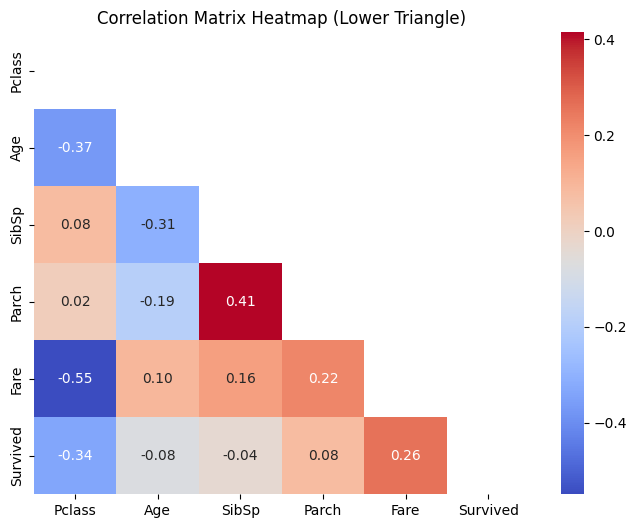

In [34]:
# Correlation matrix heatmap (lower triangle only)
corr_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']
corr_matrix = df[corr_features].corr()

# Mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
plt.title('Correlation Matrix Heatmap (Lower Triangle)')
plt.show()

- survival is positively correlated with fare and negatively correlated with passenger Pclass. 
- Age, SibSp, and Parch show weaker correlations with survival. 
- This means that ticket price and class were the most influential numerical features for predicting survival.

### Conclusions for preproccessing

1. Data is Imbalance(6:4) so we need to balance it.
2. Id ,name and ticket are not required so we will drop it .
3. Sex has two values (male,female) mapped to (0,1)
4. Cabin has huge amount of nulls(approx 70%) so dropping it
5. Embarkation will be one hot encoded.